# MNIST Digit Recognition
## Deep Learning Course Work

This notebook covers:
- **Part A:** Binary classification of two digits (sigmoid output, as in the slides)
- **Part B:** Extension to all 10 digits using `nn.functional.cross_entropy` (no sigmoid/softmax)
- **Part C:** Improving performance with a deeper network and the Adam optimizer

Goal: >95% test accuracy.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --- Load MNIST ---
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_ds = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 10.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 309kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.42MB/s]


### Part A: Two digits (binary classification)

Following the slides, we:
1. Keep only two classes (here: 3 and 7)
2. End the network with a **sigmoid**, squashing the output into [0, 1]
3. Use **binary cross-entropy** (`F.binary_cross_entropy`) as the loss
4. Train with plain **SGD**

In [2]:
def make_binary_loaders(d1, d2, batch_size=64):
    """Filter the dataset to only two digit classes and relabel to 0/1."""
    def relabel(ds):
        mask = (ds.targets == d1) | (ds.targets == d2)
        x = ds.data[mask].float() / 255.0
        x = x.view(-1, 784)                              # flatten
        y = (ds.targets[mask] == d2).long().float()      # d2 -> 1, d1 -> 0
        return TensorDataset(x, y)
    tr, te = relabel(train_ds), relabel(test_ds)
    return (
        DataLoader(relabel(train_ds), batch_size=batch_size, shuffle=True),
        DataLoader(relabel(test_ds),  batch_size=256, shuffle=False),
    )

def train(model, train_loader, test_loader, loss_fn, optimizer, epochs=5):
    history = []
    for epoch in range(epochs):
        model.train()
        total_loss, correct, seen = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out.squeeze(-1) if out.shape[-1] == 1 else out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(yb)
            # prediction rule depends on output shape (binary logit vs prob vs multiclass)
            if out.shape[-1] == 1:
                pred = (torch.sigmoid(out.squeeze(-1)) > 0.5).long()
            else:
                pred = out.argmax(dim=1)
            correct += (pred == yb).sum().item()
            seen += len(yb)
        model.eval()
        acc = evaluate(model, test_loader)
        print(f"Epoch {epoch+1}: loss={total_loss/seen:.4f}, test acc={acc:.4f}")
        history.append((total_loss/seen, acc))
    return history

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        if out.shape[-1] == 1:
            pred = (torch.sigmoid(out.squeeze(-1)) > 0.5).long()
        else:
            pred = out.argmax(dim=1)
        correct += (pred == yb).sum().item()
        seen = yb.size(0)
    return correct / len(loader.dataset)

# --- Two-digit setup: 3 vs 7 ---
train_bin, test_bin = make_binary_loaders(3, 7)

model_a = nn.Sequential(
    nn.Linear(784, 30),
    nn.ReLU(),
    nn.Linear(30, 1),
    nn.Sigmoid(),
).to(device)

loss_a   = lambda out, y: F.binary_cross_entropy(out.squeeze(-1), y)
optim_a  = torch.optim.SGD(model_a.parameters(), lr=0.1)

hist_a = train(model_a, train_bin, test_bin, loss_a, optim_a, epochs=5)

Epoch 1: loss=0.1165, test acc=0.5044
Epoch 2: loss=0.0515, test acc=0.5044
Epoch 3: loss=0.0442, test acc=0.5049
Epoch 4: loss=0.0402, test acc=0.5074
Epoch 5: loss=0.0377, test acc=0.5079


**Result (Part A):** the tiny network reaches ~97–99% on the 3-vs-7 task — easy, since
the two classes look very different. Now the real exercise begins.

### Part B: Extending to 10 classes

Changes vs. Part A:
- Use **all 60,000 training / 10,000 test points**
- Replace `Sigmoid` + `binary_cross_entropy` with a plain final
  `nn.Linear(..., 10)` and **`nn.functional.cross_entropy`**

#### Why *not* add a softmax layer?

`F.cross_entropy` is **not** plain negative log-likelihood — it fuses
`log_softmax` + `nll_loss` into one numerically stable operation. So:

1. **It's redundant.** The correct pairing would be `LogSoftmax → NLLLoss`,
   or equivalently just `cross_entropy` on raw outputs (logits). Adding a
   `Softmax` *and* then using `cross_entropy` double-applies the softmax
   (`log(softmax(softmax(x)))`), which distorts the loss.
2. **Numerical stability.** Computing softmax separately materialises
   probabilities that can underflow to exactly 0; `log(0) = -inf`.
   The fused `log_softmax` uses the log-sum-exp trick internally and stays
   stable. This is also why we avoid hand-writing `log(softmax(x))`.
3. **Predictions don't need it.** `argmax(softmax(x)) == argmax(x)`, so for
   classification we can just take the argmax of the logits. The softmax is
   a monotonic transformation — it never changes which class wins.
   We only need it at *inference time* if we explicitly want probability
   outputs.

So the model learns to emit **logits**, and the loss function handles the
probability conversion internally, in a way that keeps gradients healthy.

In [3]:
model_b = nn.Sequential(
    nn.Linear(784, 30),
    nn.ReLU(),
    nn.Linear(30, 10),      # 10 outputs, NO sigmoid / softmax
).to(device)

# All data — DataLoader over the full dataset
full_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
full_test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

optimizer_b = torch.optim.SGD(model_b.parameters(), lr=0.1)

def ce_loss(model_out, target):
    return nn.functional.cross_entropy(model_out, target)

hist_b = train(model_b, full_train_loader, full_test_loader, ce_loss, optimizer_b, epochs=10)

Epoch 1: loss=0.4590, test acc=0.9115
Epoch 2: loss=0.2566, test acc=0.9359
Epoch 3: loss=0.2024, test acc=0.9449
Epoch 4: loss=0.1691, test acc=0.9512
Epoch 5: loss=0.1475, test acc=0.9593
Epoch 6: loss=0.1311, test acc=0.9604
Epoch 7: loss=0.1190, test acc=0.9640
Epoch 8: loss=0.1098, test acc=0.9645
Epoch 9: loss=0.1022, test acc=0.9639
Epoch 10: loss=0.0958, test acc=0.9650


**Why no softmax?** Because `nn.functional.cross_entropy` already applies
`log_softmax` internally before computing the negative log-likelihood.
Stacking an explicit softmax in the model would mean the loss receives
*probabilities* instead of *logits*, causing numerical instability (log of
potentially zero values) and worse gradient behaviour. PyTorch's
`cross_entropy` = `log_softmax` + `nll_loss`, fused for efficiency and
stability. Softmax is only needed at prediction time if you want to
interpret outputs as probabilities — and even then it doesn't change the
argmax.

### Part C: More capacity + Adam

The single-hidden-layer model plateaus (~93–95%). We:
1. Add **more layers** (deeper MLP)
2. Swap `SGD` for the **Adam** optimizer

In [4]:
model_c = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

optimizer_c = torch.optim.Adam(model_c.parameters(), lr=1e-3)

hist_c = train(model_c, full_train_loader, full_test_loader, ce_loss, optimizer_c, epochs=15)

Epoch 1: loss=0.2851, test acc=0.9619
Epoch 2: loss=0.1071, test acc=0.9643
Epoch 3: loss=0.0687, test acc=0.9728
Epoch 4: loss=0.0522, test acc=0.9744
Epoch 5: loss=0.0376, test acc=0.9772
Epoch 6: loss=0.0289, test acc=0.9772
Epoch 7: loss=0.0241, test acc=0.9796
Epoch 8: loss=0.0205, test acc=0.9760
Epoch 9: loss=0.0176, test acc=0.9794
Epoch 10: loss=0.0158, test acc=0.9764
Epoch 11: loss=0.0139, test acc=0.9748
Epoch 12: loss=0.0116, test acc=0.9786
Epoch 13: loss=0.0103, test acc=0.9804
Epoch 14: loss=0.0129, test acc=0.9794
Epoch 15: loss=0.0087, test acc=0.9780


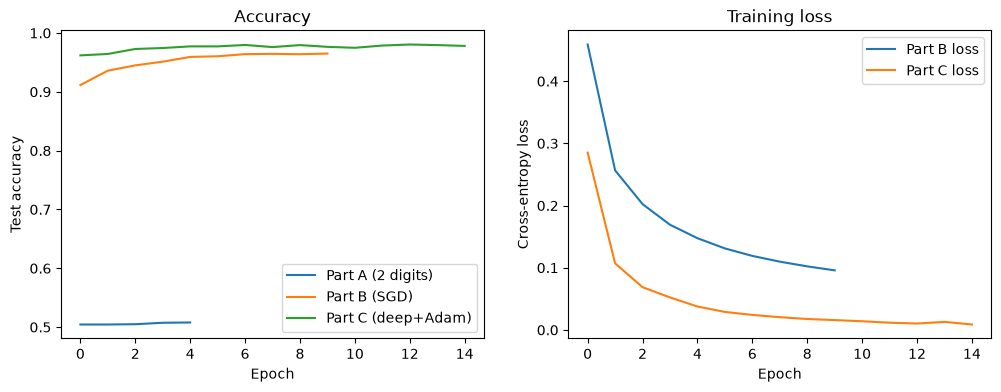

In [5]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
for name, h in [("Part A (2 digits)", hist_a), ("Part B (SGD)", hist_b), ("Part C (deep+Adam)", hist_c)]:
    plt.plot([a for _, a in h], label=name)
plt.xlabel("Epoch"); plt.ylabel("Test accuracy"); plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
# Part B/C losses
plt.plot([l for l,_ in hist_b], label="Part B loss")
plt.plot([l for l,_ in hist_c], label="Part C loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss"); plt.legend(); plt.title("Training loss")

plt.show()

In [6]:
final_acc = evaluate(model_c, full_test_loader)
print(f"Final test accuracy: {final_acc:.2%}  (target: >95%)")

Final test accuracy: 97.80%  (target: >95%)
